In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv("employee_salary_dataset.csv")

In [3]:
df

,EmployeeID,Name,Department,Experience_Years,Education_Level,Age,Gender,City,Monthly_Salary
0,1,Employee_1,Marketing,15,Master,53,Female,Delhi,111416
1,2,Employee_2,Operations,7,Bachelor,25,Female,Bangalore,95271
2,3,Employee_3,IT,12,High School,51,Female,Hyderabad,69064
3,4,Employee_4,Operations,8,PhD,44,Male,Delhi,95091
4,5,Employee_5,Operations,15,Master,36,Female,Delhi,132450
5,6,Employee_6,Finance,3,High School,50,Male,Mumbai,65818
6,7,Employee_7,IT,14,PhD,57,Male,Mumbai,70525
7,8,Employee_8,IT,17,PhD,34,Female,Bangalore,44830
8,9,Employee_9,IT,4,Bachelor,53,Male,Hyderabad,42429
9,10,Employee_10,Operations,18,High School,28,Male,Mumbai,31893


In [7]:
x=df.drop('Experience_Years',axis=1)

In [6]:
x=df.drop('Education_Level',axis=1)

In [8]:
x

,EmployeeID,Name,Department,Education_Level,Age,Gender,City,Monthly_Salary
0,1,Employee_1,Marketing,Master,53,Female,Delhi,111416
1,2,Employee_2,Operations,Bachelor,25,Female,Bangalore,95271
2,3,Employee_3,IT,High School,51,Female,Hyderabad,69064
3,4,Employee_4,Operations,PhD,44,Male,Delhi,95091
4,5,Employee_5,Operations,Master,36,Female,Delhi,132450
5,6,Employee_6,Finance,High School,50,Male,Mumbai,65818
6,7,Employee_7,IT,PhD,57,Male,Mumbai,70525
7,8,Employee_8,IT,PhD,34,Female,Bangalore,44830
8,9,Employee_9,IT,Bachelor,53,Male,Hyderabad,42429
9,10,Employee_10,Operations,High School,28,Male,Mumbai,31893


In [9]:
y=df['Education_Level']

In [10]:
df.isnull().sum()

EmployeeID          0
Name                0
Department          0
Experience_Years    0
Education_Level     0
Age                 0
Gender              0
City                0
Monthly_Salary      0
dtype: int64

In [12]:
X=df[['Age','Monthly_Salary']]
y=df['Education_Level']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [14]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [15]:
import numpy as np

In [16]:
mask = ~y_train.isnull()

X_train = X_train[mask]
y_train = y_train[mask]

In [17]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred=logreg.predict(X_test)

In [19]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[0 0 2 0]
 [0 0 3 0]
 [0 0 6 0]
 [0 0 2 0]]


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.46153846153846156
Precision: 0.11538461538461539
Recall: 0.25


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


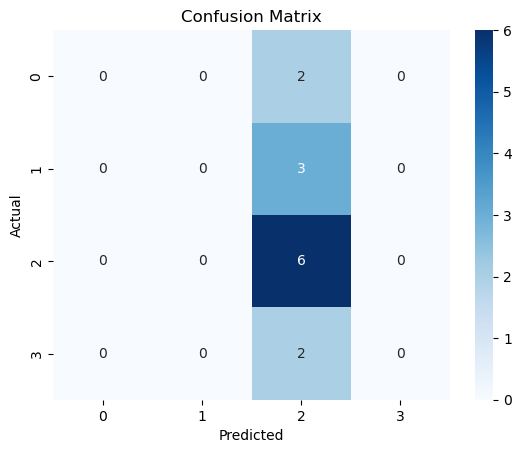

In [21]:
sns.heatmap(cm,annot=True,fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
x=np.linspace(-10,10,100)
y=1/(1+np.exp(-x))

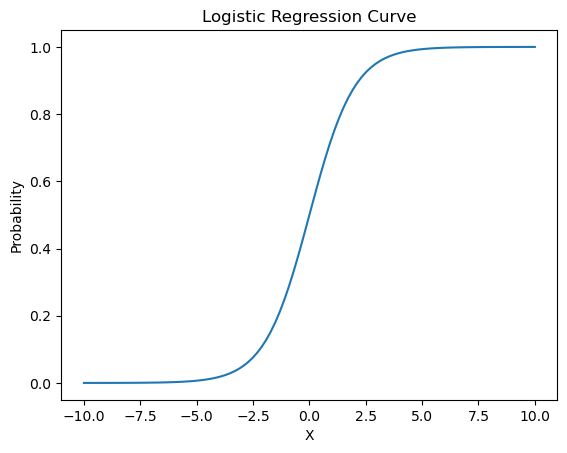

In [23]:
plt.plot(x,y)
plt.title("Logistic Regression Curve")
plt.xlabel("X")
plt.ylabel("Probability")
plt.show()